In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import json
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt
import random
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print("Setup complete, seeds fixed for reproducibility")


Setup complete, seeds fixed for reproducibility


# Efficient Loading Data

In [11]:
import time

# measure loading time for both files
start_time = time.time()

with open(DATA_PATH + "train-v2.0.json", "r", encoding="utf-8") as f:
    train_raw = json.load(f)

with open(DATA_PATH + "dev-v2.0.json", "r", encoding="utf-8") as f:
    dev_raw = json.load(f)

load_time = time.time() - start_time

print(f"Files loaded in {load_time:.2f} seconds")
print(f"Train articles: {len(train_raw['data'])}")
print(f"Dev articles:   {len(dev_raw['data'])}")
print(f"Train file keys: {list(train_raw.keys())}")

Files loaded in 0.55 seconds
Train articles: 442
Dev articles:   35
Train file keys: ['version', 'data']


# Explore the JSON structure

In [3]:
# examine the nested structure of one training example
sample_article = train_raw["data"][6]
print("Article title:", sample_article["title"])

sample_paragraph = sample_article["paragraphs"][0]
print("\nContext (first 200 chars):")
print(sample_paragraph["context"][:200])

sample_qa = sample_paragraph["qas"][0]
print("\nQuestion:", sample_qa["question"])
print("Is unanswerable:", sample_qa["is_impossible"])

if not sample_qa["is_impossible"]:
    print("Answer:", sample_qa["answers"][0]["text"])
    print("Answer start index:", sample_qa["answers"][0]["answer_start"])

Article title: 2008_Sichuan_earthquake

Context (first 200 chars):
The 2008 Sichuan earthquake or the Great Sichuan earthquake, measured at 8.0 Ms and 7.9 Mw, and occurred at 02:28:01 PM China Standard Time at epicenter (06:28:01 UTC) on May 12 in Sichuan province, k

Question: In what year did the earthquake in Sichuan occur?
Is unanswerable: False
Answer: 2008
Answer start index: 4


# Advanced Preprocessing

Context length stats (words):
  Mean:   119.8
  Median: 109.0
  Max:    499
  Min:    23

Question length stats (words):
  Mean:   10.2
  Median: 10.0
  Max:    29

Answer length stats (words):
  Mean:   2.5
  Max:    43


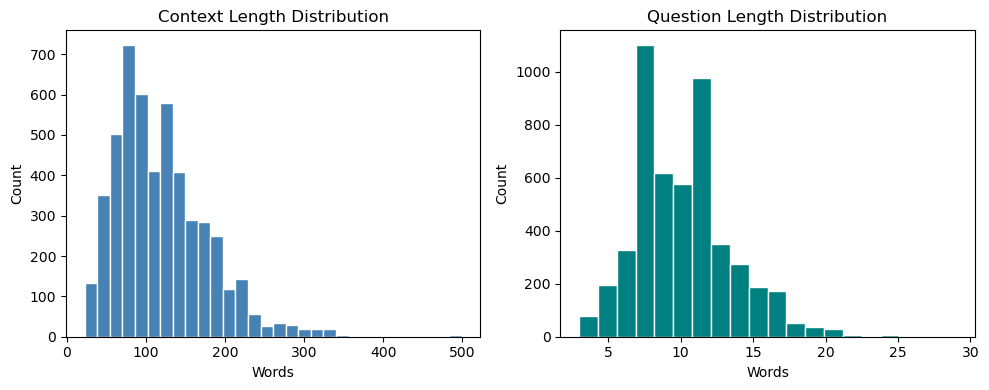

In [12]:
import numpy as np

# compute preprocessing statistics
context_lengths = [len(c.split()) for c in train_contexts]
question_lengths = [len(q.split()) for q in train_questions]
answer_lengths = [len(a["text"].split()) for a in train_answers]

print("Context length stats (words):")
print(f"  Mean:   {np.mean(context_lengths):.1f}")
print(f"  Median: {np.median(context_lengths):.1f}")
print(f"  Max:    {np.max(context_lengths)}")
print(f"  Min:    {np.min(context_lengths)}")

print("\nQuestion length stats (words):")
print(f"  Mean:   {np.mean(question_lengths):.1f}")
print(f"  Median: {np.median(question_lengths):.1f}")
print(f"  Max:    {np.max(question_lengths)}")

print("\nAnswer length stats (words):")
print(f"  Mean:   {np.mean(answer_lengths):.1f}")
print(f"  Max:    {np.max(answer_lengths)}")

# visualise context length distribution
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(context_lengths, bins=30, color="steelblue", edgecolor="white")
plt.title("Context Length Distribution")
plt.xlabel("Words")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
plt.hist(question_lengths, bins=20, color="teal", edgecolor="white")
plt.title("Question Length Distribution")
plt.xlabel("Words")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

# Extract all QA triples

In [48]:
def extract_qa_pairs(raw_data):
    contexts = []
    questions = []
    answers = []
    unanswerable_count = 0

    for article in raw_data["data"]:
        for paragraph in article["paragraphs"]:
            context = paragraph["context"]
            for qa in paragraph["qas"]:
                if qa["is_impossible"]:
                    # unanswerable questions are counted but excluded from training
                    unanswerable_count += 1
                else:
                    contexts.append(context)
                    questions.append(qa["question"])
                    answers.append({
                        "text": qa["answers"][0]["text"],
                        "answer_start": qa["answers"][0]["answer_start"]
                    })

    print(f"Answerable:   {len(contexts)}")
    print(f"Unanswerable: {unanswerable_count}")
    print(f"Unanswerable ratio: {unanswerable_count/(len(contexts)+unanswerable_count)*100:.1f}%")

    return contexts, questions, answers

train_contexts, train_questions, train_answers = extract_qa_pairs(train_raw)
print("---")
dev_contexts, dev_questions, dev_answers = extract_qa_pairs(dev_raw)

Answerable:   86821
Unanswerable: 43498
Unanswerable ratio: 33.4%
---
Answerable:   5928
Unanswerable: 5945
Unanswerable ratio: 50.1%


# Take subset for Training

In [60]:
# subset size chosen based on available hardware memory
SUBSET_SIZE = 5000

train_contexts = train_contexts[:SUBSET_SIZE]
train_questions = train_questions[:SUBSET_SIZE]
train_answers = train_answers[:SUBSET_SIZE]

print("Training subset size:", len(train_contexts))
print("Dev set size (full):", len(dev_contexts))
print("\nSample context:")
print(train_contexts[0][:200])
print("\nSample question:", train_questions[0])
print("Sample answer:", train_answers[0])

Training subset size: 5000
Dev set size (full): 5928

Sample context:
Beyoncé Giselle Knowles-Carter (/biːˈjɒnseɪ/ bee-YON-say) (born September 4, 1981) is an American singer, songwriter, record producer and actress. Born and raised in Houston, Texas, she performed in v

Sample question: When did Beyonce start becoming popular?
Sample answer: {'text': 'in the late 1990s', 'answer_start': 269}


# Convert Character position to token position

In [61]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_CONTEXT_LEN  = 300
MAX_QUESTION_LEN = 50

# tokenizer fit on combined context and question vocabulary
tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(train_contexts + train_questions)

vocab_size = len(tokenizer.word_index) + 1
print("Vocabulary size:", vocab_size)

train_context_seq  = tokenizer.texts_to_sequences(train_contexts)
train_question_seq = tokenizer.texts_to_sequences(train_questions)
dev_context_seq    = tokenizer.texts_to_sequences(dev_contexts)
dev_question_seq   = tokenizer.texts_to_sequences(dev_questions)

train_context_pad  = pad_sequences(train_context_seq,  maxlen=MAX_CONTEXT_LEN,  padding="post", truncating="post")
train_question_pad = pad_sequences(train_question_seq, maxlen=MAX_QUESTION_LEN, padding="post", truncating="post")
dev_context_pad    = pad_sequences(dev_context_seq,    maxlen=MAX_CONTEXT_LEN,  padding="post", truncating="post")
dev_question_pad   = pad_sequences(dev_question_seq,   maxlen=MAX_QUESTION_LEN, padding="post", truncating="post")

print("Train context shape:", train_context_pad.shape)
print("Train question shape:", train_question_pad.shape)
print("Dev context shape:", dev_context_pad.shape)
print("Dev question shape:", dev_question_pad.shape)

Vocabulary size: 13680
Train context shape: (5000, 300)
Train question shape: (5000, 50)
Dev context shape: (5928, 300)
Dev question shape: (5928, 50)


# Load GloVE Vectors

In [62]:
GLOVE_PATH = "data/glove.6B/glove.6B.100d.txt"
EMBEDDING_DIM = 100

glove_embeddings = {}

with open(GLOVE_PATH, "r", encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.array(values[1:], dtype="float32")
        glove_embeddings[word] = vector

print("GloVe vectors loaded:", len(glove_embeddings))
print("Embedding dimension:", EMBEDDING_DIM)

GloVe vectors loaded: 400000
Embedding dimension: 100


# Build Embedding Matrix with OOV Handling

In [63]:
oov_count = 0
found_count = 0

# initialise matrix with zeros, shape is vocab size x embedding dim
embedding_matrix = np.zeros((vocab_size, EMBEDDING_DIM))

for word, index in tokenizer.word_index.items():
    vector = glove_embeddings.get(word)
    if vector is not None:
        embedding_matrix[index] = vector
        found_count += 1
    else:
        # words not found in GloVe remain as zero vectors
        oov_count += 1

print("Embedding matrix shape:", embedding_matrix.shape)
print("Words found in GloVe:", found_count)
print("OOV words (zero vectors):", oov_count)
print(f"GloVe coverage: {found_count/(found_count+oov_count)*100:.1f}%")

Embedding matrix shape: (13680, 100)
Words found in GloVe: 12453
OOV words (zero vectors): 1226
GloVe coverage: 91.0%


# BiLSTM

In [64]:
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.models import Model

LSTM_UNITS = 128

# context input
context_input = Input(shape=(MAX_CONTEXT_LEN,), name="context_input")
context_embed = Embedding(
    input_dim=vocab_size,
    output_dim=EMBEDDING_DIM,
    weights=[embedding_matrix],
    trainable=False,
    name="context_embedding"
)(context_input)

# question input
question_input = Input(shape=(MAX_QUESTION_LEN,), name="question_input")
question_embed = Embedding(
    input_dim=vocab_size,
    output_dim=EMBEDDING_DIM,
    weights=[embedding_matrix],
    trainable=False,
    name="question_embedding"
)(question_input)

# bidirectional LSTM encodes context
context_encoded = Bidirectional(
    LSTM(LSTM_UNITS, return_sequences=True, dropout=0.3),
    name="context_bilstm"
)(context_embed)

# bidirectional LSTM encodes question
question_encoded = Bidirectional(
    LSTM(LSTM_UNITS, return_sequences=False, dropout=0.3),
    name="question_bilstm"
)(question_embed)

print("Context encoded shape:", context_encoded.shape)
print("Question encoded shape:", question_encoded.shape)

Context encoded shape: (None, 300, 256)
Question encoded shape: (None, 256)


# Attention Layer

In [65]:
from tensorflow.keras.layers import Concatenate, Lambda
import tensorflow as tf

# concatenate question vector with each context token position
question_expanded = Lambda(
    lambda x: tf.tile(tf.expand_dims(x, 1), [1, MAX_CONTEXT_LEN, 1])
)(question_encoded)

combined = Concatenate()([context_encoded, question_expanded])

# compute attention scores through dense layers for stable gradients
attention_scores  = Dense(128, activation="tanh")(combined)
attention_scores  = Dense(1)(attention_scores)
attention_weights = Lambda(
    lambda x: tf.squeeze(x, axis=-1), name="attention_weights"
)(attention_scores)
attention_weights = Activation("softmax")(attention_weights)

# apply attention weights to context hidden states
attention_expanded = Lambda(
    lambda x: tf.expand_dims(x, -1)
)(attention_weights)
context_attended = Lambda(
    lambda x: tf.reduce_sum(x[0] * x[1], axis=1)
)([context_encoded, attention_expanded])

print("Attention weights shape:", attention_weights.shape)
print("Attended context shape:", context_attended.shape)

Attention weights shape: (None, 300)
Attended context shape: (None, 256)


# Output Layer

In [66]:
from tensorflow.keras.layers import TimeDistributed, Lambda
import tensorflow as tf

# predict start position across all context tokens
start_output = Dense(MAX_CONTEXT_LEN, activation="softmax", name="start_position")(context_attended)

# predict end position across all context tokens
end_output = Dense(MAX_CONTEXT_LEN, activation="softmax", name="end_position")(context_attended)

print("Start output shape:", start_output.shape)
print("End output shape:", end_output.shape)

Start output shape: (None, 300)
End output shape: (None, 300)


# Build and Compile File Model

In [67]:
model = Model(
    inputs=[context_input, question_input],
    outputs=[start_output, end_output]
)

model.compile(
    optimizer="adam",
    loss=["sparse_categorical_crossentropy", "sparse_categorical_crossentropy"],
    metrics=["accuracy", "accuracy"]
)

print("Model compiled")
print("Output names:", [o.name for o in model.outputs])
model.summary()

Model compiled
Output names: ['keras_tensor_128', 'keras_tensor_129']


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ question_input      │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ context_input       │ (None, 300)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ question_embedding  │ (None, 50, 100)   │  1,368,000 │ question_input[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ context_embedding   │ (None, 300, 100)  │  1,368,000 │ context_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ question_bilstm     │ (None, 256)       │    234,496 │ question_embeddi… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ context_bilstm      │ (None, 300, 256)  │    234,496 │ context_embeddin… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_10 (Lambda)  │ (None, 300, 256)  │          0 │ question_bilstm[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 300, 512)  │          0 │ context_bilstm[0… │
│ (Concatenate)       │                   │            │ lambda_10[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 300, 128)  │     65,664 │ concatenate_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 300, 1)    │        129 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_weights   │ (None, 300)       │          0 │ dense_7[0][0]     │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_8        │ (None, 300)       │          0 │ attention_weight… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_11 (Lambda)  │ (None, 300, 1)    │          0 │ activation_8[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_12 (Lambda)  │ (None, 256)       │          0 │ context_bilstm[0… │
│                     │                   │            │ lambda_11[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ start_position      │ (None, 300)       │     77,100 │ lambda_12[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ end_position        │ (None, 300)       │     77,100 │ lambda_12[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,424,985 (13.07 MB)

 Trainable params: 688,985 (2.63 MB)

 Non-trainable params: 2,736,000 (10.44 MB)

# Prepare Answer Position Labels

In [68]:
def get_token_positions(contexts, answers, tokenizer, max_len):
    start_positions = []
    end_positions = []

    for i in range(len(answers)):
        answer_text = answers[i]["text"].lower()
        answer_start_char = answers[i]["answer_start"]
        context = contexts[i].lower()

        # split context into words and track character offsets
        words = context.split()
        char_count = 0
        start_tok = 0
        end_tok = 0
        found = False

        for idx, word in enumerate(words):
            word_start = char_count
            word_end = char_count + len(word)

            if not found and word_start <= answer_start_char <= word_end:
                start_tok = idx
                found = True

            if found and word_end >= answer_start_char + len(answer_text) - 1:
                end_tok = idx
                break

            char_count += len(word) + 1

        # clip to max context length
        start_tok = min(start_tok, max_len - 1)
        end_tok   = min(end_tok,   max_len - 1)

        # ensure end is never before start
        if end_tok < start_tok:
            end_tok = start_tok

        start_positions.append(start_tok)
        end_positions.append(end_tok)

    return np.array(start_positions), np.array(end_positions)

train_start, train_end = get_token_positions(
    train_contexts, train_answers, tokenizer, MAX_CONTEXT_LEN)
dev_start, dev_end = get_token_positions(
    dev_contexts, dev_answers, tokenizer, MAX_CONTEXT_LEN)

print("Train start positions shape:", train_start.shape)
print("Train end positions shape:",   train_end.shape)
print("Sample start:", train_start[0], "| Sample end:", train_end[0])
print("Sample answer text:", train_answers[0]["text"])

Train start positions shape: (5000,)
Train end positions shape: (5000,)
Sample start: 39 | Sample end: 42
Sample answer text: in the late 1990s


# Training the model

In [69]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# train the model
history = model.fit(
    [train_context_pad, train_question_pad],
    [train_start, train_end],
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

print("Training complete")

Epoch 1/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 24s 159ms/step - end_position_accuracy: 0.0138 - end_position_loss: 5.0852 - loss: 10.1535 - start_position_accuracy: 0.0244 - start_position_loss: 5.0664 - val_end_position_accuracy: 0.0160 - val_end_position_loss: 5.0165 - val_loss: 10.0132 - val_start_position_accuracy: 0.0100 - val_start_position_loss: 4.9754
Epoch 2/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 25s 179ms/step - end_position_accuracy: 0.0180 - end_position_loss: 4.9307 - loss: 9.8405 - start_position_accuracy: 0.0258 - start_position_loss: 4.9085 - val_end_position_accuracy: 0.0100 - val_end_position_loss: 5.0146 - val_loss: 10.0027 - val_start_position_accuracy: 0.0180 - val_start_position_loss: 4.9665
Epoch 3/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 27s 193ms/step - end_position_accuracy: 0.0211 - end_position_loss: 4.8999 - loss: 9.7788 - start_position_accuracy: 0.0273 - start_position_loss: 4.8777 - val_end_position_accuracy: 0.0140 - val_end_position_loss: 5.0179 - val_loss: 10.0123 - val_sta

# Predict on Devset

In [71]:
# generate predictions on dev set
start_preds, end_preds = model.predict(
    [dev_context_pad, dev_question_pad],
    verbose=1
)

# take argmax to get predicted token positions
pred_start = np.argmax(start_preds, axis=1)
pred_end   = np.argmax(end_preds,   axis=1)

print("Predictions generated:", len(pred_start))
print("Sample pred start:", pred_start[0], "| pred end:", pred_end[0])
print("Actual start:", dev_start[0], "| actual end:", dev_end[0])

186/186 ━━━━━━━━━━━━━━━━━━━━ 18s 95ms/step
Predictions generated: 5928
Sample pred start: 0 | pred end: 1
Actual start: 26 | actual end: 26


# Evaluation Matrics

In [72]:
from collections import Counter

def compute_f1(predicted_tokens, actual_tokens):
    common = Counter(predicted_tokens) & Counter(actual_tokens)
    num_same = sum(common.values())
    if num_same == 0:
        return 0.0
    precision = num_same / len(predicted_tokens)
    recall    = num_same / len(actual_tokens)
    f1 = (2 * precision * recall) / (precision + recall)
    return f1

def compute_em(predicted_tokens, actual_tokens):
    return int(predicted_tokens == actual_tokens)

def evaluate_predictions(contexts, pred_start, pred_end,
                         actual_start, actual_end):
    f1_scores = []
    em_scores = []

    for i in range(len(contexts)):
        words = contexts[i].lower().split()

        # extract predicted and actual answer spans
        pred_span   = words[pred_start[i]:pred_end[i]+1]
        actual_span = words[actual_start[i]:actual_end[i]+1]

        f1_scores.append(compute_f1(pred_span, actual_span))
        em_scores.append(compute_em(pred_span, actual_span))

    avg_f1 = np.mean(f1_scores) * 100
    avg_em = np.mean(em_scores) * 100
    return avg_f1, avg_em

f1, em = evaluate_predictions(
    dev_contexts, pred_start, pred_end, dev_start, dev_end)

print("=" * 40)
print(f"Exact Match (EM): {em:.2f}%")
print(f"F1 Score:         {f1:.2f}%")
print("=" * 40)
print(f"Paper baseline F1 (logistic regression): 51.0%")
print(f"Human performance F1:                    86.8%")

Exact Match (EM): 0.66%
F1 Score:         4.89%
Paper baseline F1 (logistic regression): 51.0%
Human performance F1:                    86.8%


# Sample Pridiction

In [44]:
print("SAMPLE PREDICTIONS ON DEV SET")
print("=" * 60)

for i in range(5):
    words = dev_contexts[i].lower().split()

    pred_span   = " ".join(words[pred_start[i]:pred_end[i]+1])
    actual_span = " ".join(words[dev_start[i]:dev_end[i]+1])

    print(f"Example {i+1}")
    print(f"Question:  {dev_questions[i]}")
    print(f"Predicted: {pred_span}")
    print(f"Actual:    {actual_span}")
    print(f"F1:        {compute_f1(pred_span.split(), actual_span.split()):.2f}")
    print("-" * 60)

SAMPLE PREDICTIONS ON DEV SET
Example 1
Question:  In what country is Normandy located?
Predicted: the normans
Actual:    france.
F1:        0.00
------------------------------------------------------------
Example 2
Question:  When were the Normans in Normandy?
Predicted: the normans
Actual:    10th and 11th centuries
F1:        0.00
------------------------------------------------------------
Example 3
Question:  From which countries did the Norse originate?
Predicted: the normans
Actual:    denmark, iceland and norway
F1:        0.00
------------------------------------------------------------
Example 4
Question:  Who was the Norse leader?
Predicted: the normans
Actual:    rollo,
F1:        0.00
------------------------------------------------------------
Example 5
Question:  What century did the Normans first gain their separate identity?
Predicted: the normans
Actual:    10th century,
F1:        0.00
------------------------------------------------------------


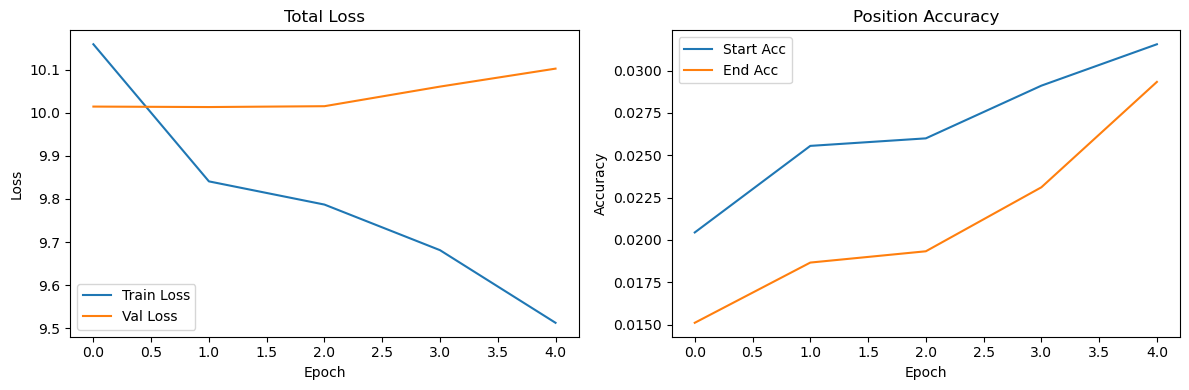

In [45]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Total Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["start_position_accuracy"], label="Start Acc")
plt.plot(history.history["end_position_accuracy"], label="End Acc")
plt.title("Position Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()